# Import libraries and the dataset

In [ ]:
!pip install -q timm

In [ ]:
import tensorflow as tf
import kagglehub
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import WeightedRandomSampler
import time
import timm
import torch
import torch.nn as nn
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU Available: {len(gpus)} GPU(s) detected")
    for gpu in gpus:
        print(f"  - {gpu}")
    # Set memory growth to avoid VRAM issues
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled (prevents VRAM errors)")
else:
    print("No GPU detected - training will be MUCH slower!")
    print("Enable GPU: Runtime → Change runtime type → GPU")

✓ GPU Available: 1 GPU(s) detected
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth enabled (prevents VRAM errors)


In [ ]:
path = kagglehub.dataset_download("danielagluj/sleep-30s-spectrograms-from-dodh-dataset")
DATASET_PATH = Path(path)
TRAIN_DIR = DATASET_PATH / "sleep_spectrogram_dataset"
TEST_DIR  = DATASET_PATH / "test_set_unseen_sub015"
print(f"Train directory: {TRAIN_DIR}")
print(f"Test directory:  {TEST_DIR}")
print(f"Total train images: {sum(1 for _ in TRAIN_DIR.rglob('*.png')):,}")
print(f"Total test images:  {sum(1 for _ in TEST_DIR.rglob('*.png')):,}")

Using Colab cache for faster access to the 'sleep-30s-spectrograms-from-dodh-dataset' dataset.
Train directory: /kaggle/input/sleep-30s-spectrograms-from-dodh-dataset/sleep_spectrogram_dataset
Test directory:  /kaggle/input/sleep-30s-spectrograms-from-dodh-dataset/test_set_unseen_sub015
Total train images: 4,649
Total test images:  929


# Explore the dataset

In [ ]:
CLASS_ORDER = ['W', 'N1', 'N2', 'N3', 'REM']
# Function to count images in each class
def count_images_per_class(root_dir: Path):
    data = []
    for class_dir in root_dir.iterdir():
        if not class_dir.is_dir():
            continue
        cls = class_dir.name
        count = len(list(class_dir.glob("*.png")))
        data.append({"class": cls, "count": count})
    df = pd.DataFrame(data)
    total = df["count"].sum()
    df["percentage"] = (df["count"] / total * 100).round(1)
    df = df.set_index('class').reindex(CLASS_ORDER).reset_index()
    return df

In [ ]:
# Function to plot graph
def plot_bar_distribution(df: pd.DataFrame, title: str, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=df,
        x="class",
        y="percentage",
        hue="class",
        palette="viridis",
        legend=False,
        edgecolor=".3",
        ax=ax
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel("Sleep Stage", fontsize=11)
    ax.set_ylabel("Proportion", fontsize=11)
    ax.set_yticks([])
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis="x", rotation=0, labelsize=11)
    return ax

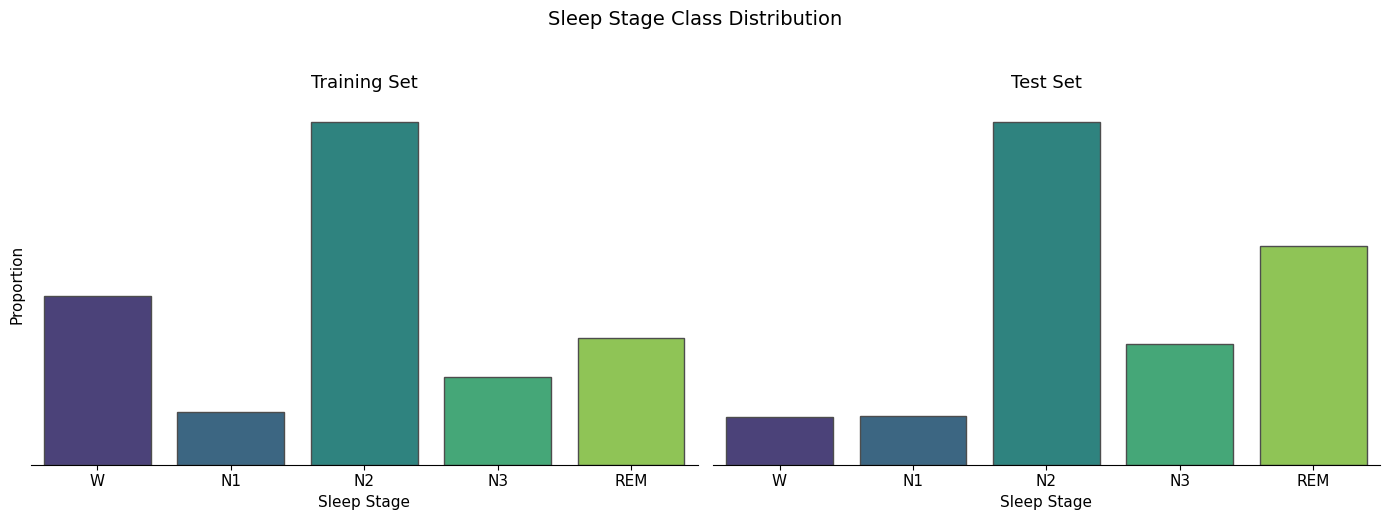

In [ ]:
df_train = count_images_per_class(TRAIN_DIR)
df_test  = count_images_per_class(TEST_DIR)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_bar_distribution(df_train, "Training Set", ax=ax1)
plot_bar_distribution(df_test, "Test Set", ax=ax2)
plt.suptitle("Sleep Stage Class Distribution", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# Function to display samples of each stage
def show_samples_per_class(root_dir, CLASS_ORDER, samples_per_class=4):
    fig, axes = plt.subplots(len(CLASS_ORDER), samples_per_class, figsize=(samples_per_class*3, len(CLASS_ORDER)*3))
    fig.suptitle("Sample Spectrograms per Sleep Stage", fontsize=16)
    for row, cls in enumerate(CLASS_ORDER):
        class_path = root_dir / cls
        if not class_path.exists():
            continue
        images = list(class_path.glob("*.png"))
        selected = random.sample(images, min(samples_per_class, len(images)))
        axes[row, 0].text(-0.1, 0.5, cls, va='center', ha='right', fontsize=14, transform=axes[row,0].transAxes)
        for col, img_path in enumerate(selected):
            img = Image.open(img_path)
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

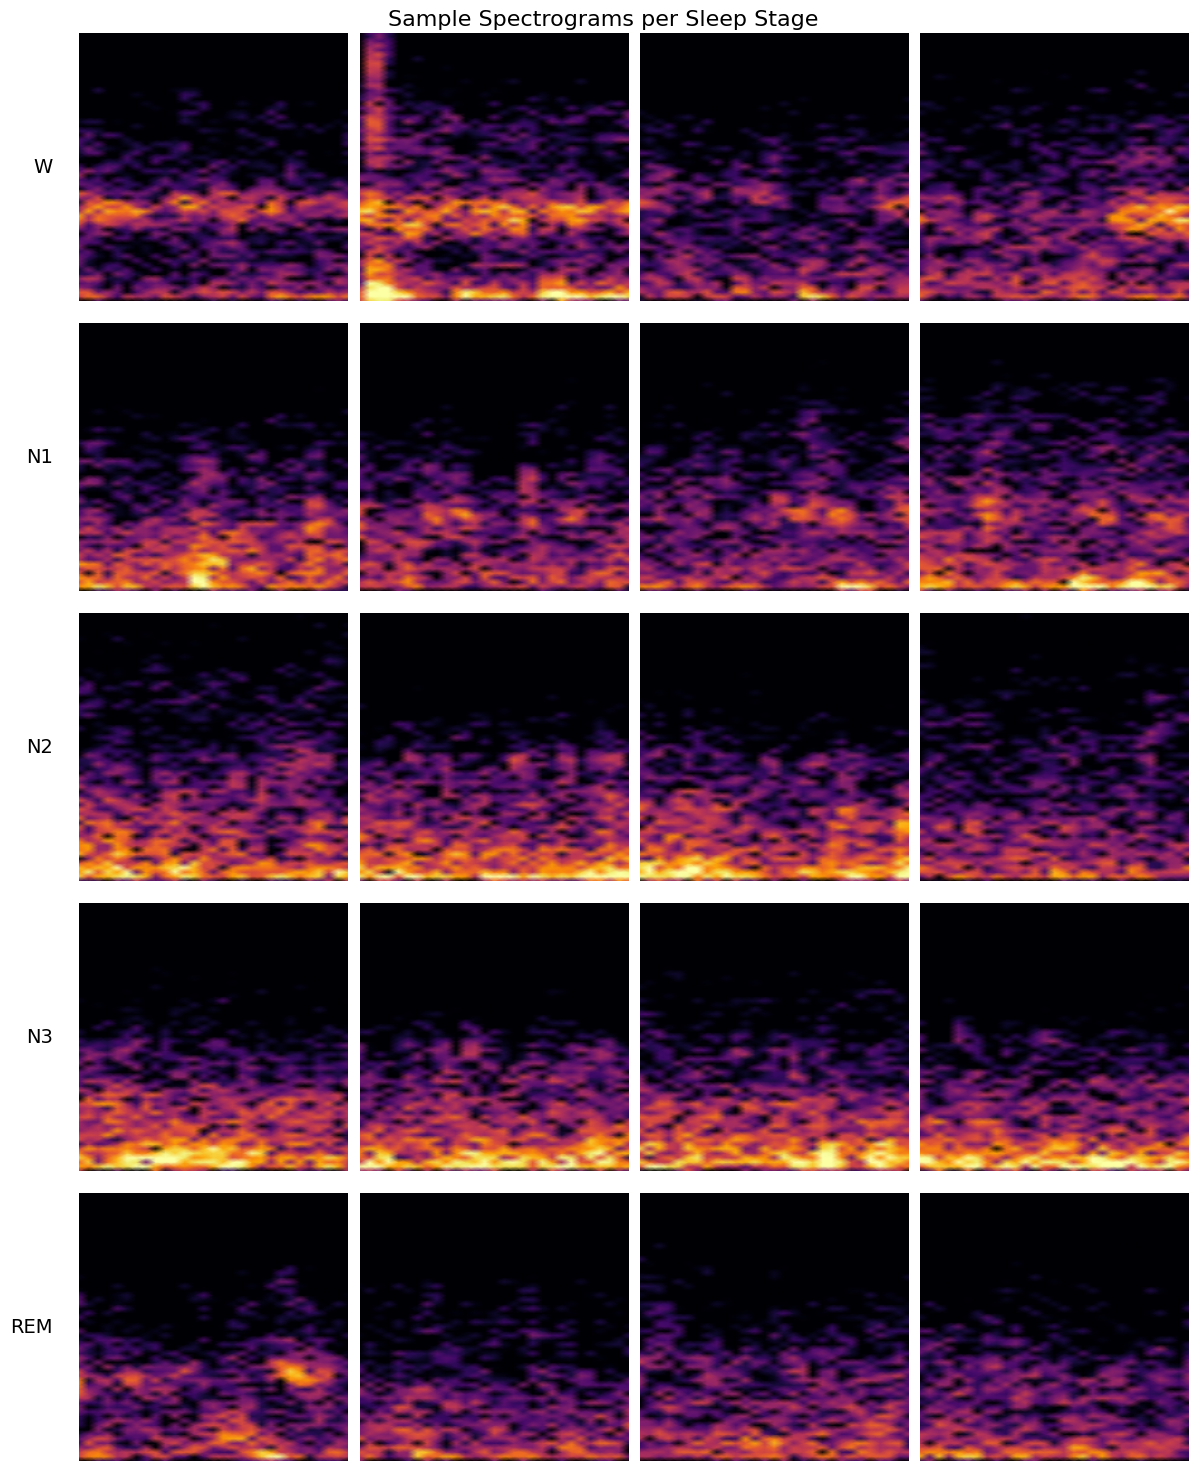

In [ ]:
show_samples_per_class(TRAIN_DIR, CLASS_ORDER)

In [ ]:
# Function to check the size of image
def check_image_sizes(root_dir, max_samples=50):
    sizes = []
    for cls_dir in root_dir.iterdir():
        if not cls_dir.is_dir(): continue
        imgs = list(cls_dir.glob("*.png"))[:max_samples//5]  # limit per class
        for img_path in imgs:
            with Image.open(img_path) as im:
                sizes.append(im.size)
    unique_sizes = set(sizes)
    print(f"Unique image sizes: {unique_sizes}")
    print(f"Most common: {max(set(sizes), key=sizes.count)}")
check_image_sizes(TRAIN_DIR)
check_image_sizes(TEST_DIR)

Unique image sizes: {(300, 300)}
Most common: (300, 300)
Unique image sizes: {(300, 300)}
Most common: (300, 300)


# Preprocessing

In [ ]:
# Resize, augmentation, normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR,  transform=test_transform)
print(f"Train: {len(train_dataset):,} images")
print(f"Test: {len(test_dataset):,} images")

# Weighted sampler
class_counts = [len(list((TRAIN_DIR / cls).glob("*.png")))
                for cls in train_dataset.classes]

weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [weights[label] for label in train_dataset.targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
BATCH_SIZE = 48
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2,
                         shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready!")

Train: 4,649 images
Test: 929 images
DataLoaders ready!


In [ ]:
model_name = "efficientnet_b2"
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=5,
    drop_rate=0.3,
    drop_path_rate=0.2
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model loaded: {model_name}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"Device: {device}")

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Model loaded: efficientnet_b2
Parameters: 7.7M
Device: cuda


In [ ]:
EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 80
PATIENCE      = 15

# Class weight to handle class imbalance
class_counts = torch.zeros(5)
for _, labels in train_loader:
    for c in range(5):
        class_counts[c] += (labels == c).sum()
class_weights = (1.0 / (class_counts + 1e-6))
class_weights = class_weights / class_weights.sum() * 5
class_weights = class_weights.to(device)
print("Class weights:", [f"{w:.3f}" for w in class_weights.tolist()])

# Cross Entropy Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scaler = torch.amp.GradScaler('cuda')

def train_epoch(loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def eval_epoch(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            with torch.autocast(device_type='cuda'):
                preds = model(images).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
    kappa = cohen_kappa_score(all_labels, all_preds)
    return acc, kappa, all_preds, all_labels

# Training loop
def run_phase(phase_name, epochs, optimizer, scheduler):
    best_kappa, best_state = -1.0, None
    history = {"train_loss": [], "train_acc": [], "test_acc": [], "test_kappa": []}
    no_improve = 0

    print(f"{phase_name} ({epochs} epochs, patience={PATIENCE})")

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_epoch(train_loader, optimizer, scheduler)
        test_acc, test_kappa, _, _ = eval_epoch(test_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["test_kappa"].append(test_kappa)

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
              f"Test Acc: {test_acc:.3f} | κ: {test_kappa:.4f} | "
              f"{time.time()-t0:.1f}s")

        if test_kappa > best_kappa:
            best_kappa  = test_kappa
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve  = 0
            print(f" =====> Best κ={best_kappa:.4f} saved!")
        else:
            no_improve += 1
            print(f"No improvement ({no_improve}/{PATIENCE})")
            if no_improve >= PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}!")
                break

    model.load_state_dict(best_state)
    print(f"\n{phase_name} complete. Best κ = {best_kappa:.4f}")
    return history

print("Functions ready!")

Class weights: ['1.008', '1.012', '1.028', '1.008', '0.945']
Functions ready!


In [ ]:
# Frozen backbone
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=1e-3, weight_decay=1e-4)
scheduler1 = OneCycleLR(optimizer1, max_lr=1e-3,
                        steps_per_epoch=len(train_loader),
                        epochs=EPOCHS_PHASE1, pct_start=0.3)

history_p1 = run_phase("PHASE 1: Head Only", EPOCHS_PHASE1, optimizer1, scheduler1)

# Full Fine-tune
for param in model.parameters():
    param.requires_grad = True

backbone_params = [p for n, p in model.named_parameters() if "classifier" not in n]
head_params = [p for n, p in model.named_parameters() if "classifier" in n]

optimizer2 = optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},
    {"params": head_params, "lr": 5e-4},
], weight_decay=1e-4)
scheduler2 = OneCycleLR(optimizer2, max_lr=[1e-4, 5e-4],
                        steps_per_epoch=len(train_loader),
                        epochs=EPOCHS_PHASE2, pct_start=0.1)

history_p2 = run_phase("PHASE 2: Full Fine-tuning", EPOCHS_PHASE2, optimizer2, scheduler2)

PHASE 1: Head Only (20 epochs, patience=20)
Epoch   1/20 | Train Loss: 4.5850 | Train Acc: 0.207 | Test Acc: 0.268 | κ: 0.0298 | 60.5s
Best κ=0.0298 saved!
Epoch   2/20 | Train Loss: 4.3038 | Train Acc: 0.197 | Test Acc: 0.283 | κ: 0.0606 | 39.9s
Best κ=0.0606 saved!
Epoch   3/20 | Train Loss: 3.7697 | Train Acc: 0.227 | Test Acc: 0.365 | κ: 0.1640 | 37.7s
Best κ=0.1640 saved!
Epoch   4/20 | Train Loss: 3.1719 | Train Acc: 0.295 | Test Acc: 0.429 | κ: 0.2514 | 36.8s
Best κ=0.2514 saved!
Epoch   5/20 | Train Loss: 2.6879 | Train Acc: 0.374 | Test Acc: 0.512 | κ: 0.3592 | 37.1s
Best κ=0.3592 saved!
Epoch   6/20 | Train Loss: 2.3971 | Train Acc: 0.434 | Test Acc: 0.549 | κ: 0.4116 | 37.5s
Best κ=0.4116 saved!
Epoch   7/20 | Train Loss: 2.2204 | Train Acc: 0.468 | Test Acc: 0.587 | κ: 0.4574 | 37.0s
Best κ=0.4574 saved!
Epoch   8/20 | Train Loss: 2.1111 | Train Acc: 0.485 | Test Acc: 0.621 | κ: 0.4965 | 36.9s
Best κ=0.4965 saved!
Epoch   9/20 | Train Loss: 2.0378 | Train Acc: 0.505 | Test 

# Evaluation

In [ ]:
# Final evaluation
test_acc, test_kappa, preds, labels = eval_epoch(test_loader)
print(f"FINAL RESULTS")
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Cohen's κ: {test_kappa:.4f}")
print(f"\n{classification_report(labels, preds, target_names=CLASS_ORDER)}")

FINAL RESULTS
Accuracy : 0.8611 (86.11%)
Cohen's κ: 0.7974

              precision    recall  f1-score   support

           W       0.56      0.24      0.34        58
          N1       0.89      0.93      0.91       409
          N2       0.97      0.88      0.92       144
          N3       0.81      0.87      0.84       261
         REM       0.78      0.91      0.84        57

    accuracy                           0.86       929
   macro avg       0.80      0.77      0.77       929
weighted avg       0.85      0.86      0.85       929



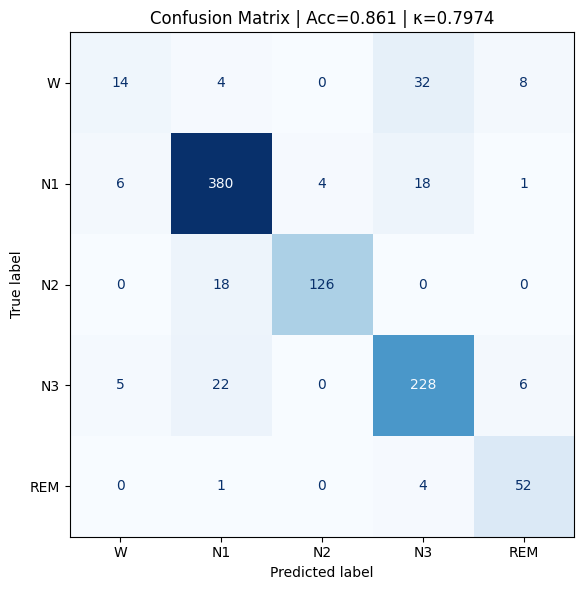

In [ ]:
# Confusion matrix
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix | Acc={test_acc:.3f} | κ={test_kappa:.4f}")
plt.tight_layout()
plt.show()

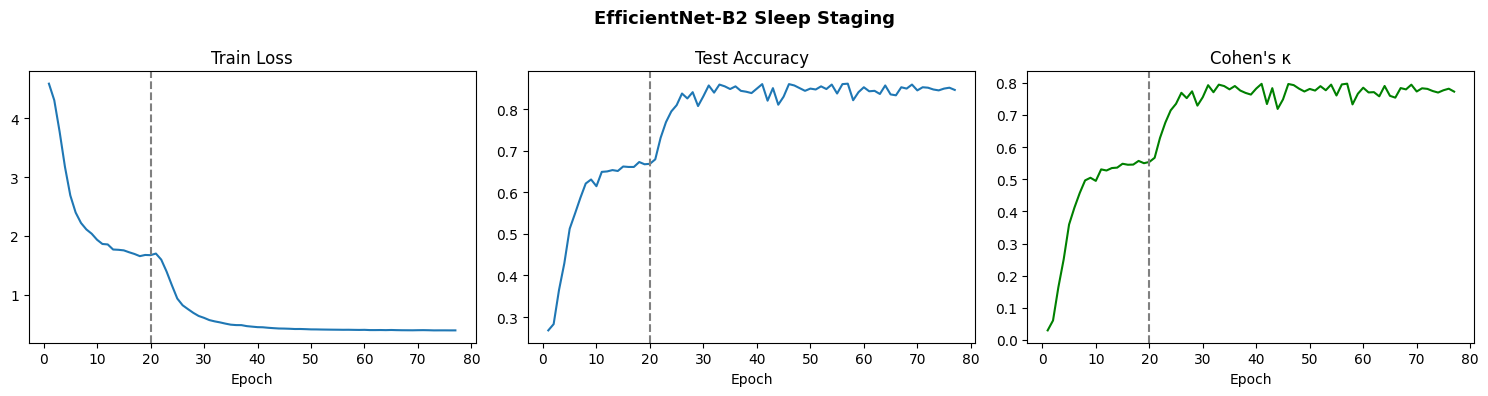

In [ ]:
# Training curves
p1_len = len(history_p1["train_loss"])
p2_len = len(history_p2["train_loss"])
all_epochs = list(range(1, p1_len + p2_len + 1))
all_loss = history_p1["train_loss"] + history_p2["train_loss"]
all_acc = history_p1["test_acc"]   + history_p2["test_acc"]
all_kappa = history_p1["test_kappa"] + history_p2["test_kappa"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(all_epochs, all_loss); axes[0].set(title="Train Loss",    xlabel="Epoch")
axes[1].plot(all_epochs, all_acc); axes[1].set(title="Test Accuracy", xlabel="Epoch")
axes[2].plot(all_epochs, all_kappa, color="green");   axes[2].set(title="Cohen's κ",     xlabel="Epoch")
for ax in axes:
    ax.axvline(p1_len, color="gray", linestyle="--", label="Phase 2 start")
plt.suptitle("EfficientNet-B2 Sleep Staging", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()